# Numerical Integration Methods in Python

## Project Objective

This project implements and compares classical numerical integration methods for approximating definite integrals.

The focus is on:

- Mathematical understanding
- Numerical implementation
- Accuracy comparison
- Convergence behavior
- Practical interpretation

## Methods Studied

1. Trapezoidal Rule
2. Simpson's Rule
3. Monte Carlo Integration

## Test Integral

We approximate the definite integral:

\[
I = \int_0^1 e^{-x^2}\,dx
\]

This integral is useful as a test case because \(e^{-x^2}\) does not have a simple elementary antiderivative, so numerical approximation methods are required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Function Definition

We define the function:

\[
f(x) = e^{-x^2}
\]

The goal is to approximate the area under this curve from \(x=0\) to \(x=1\).

In [3]:
def f(x):
    return np.exp(-x**2)

a = 0
b = 1

In [4]:
print("f(0) =", f(0))
print("f(1) =", f(1))

f(0) = 1.0
f(1) = 0.36787944117144233


## Visualization of the Integral

A definite integral represents the signed area under a curve over a given interval.

Here, we approximate the area under:

\[
f(x)=e^{-x^2}
\]

from \(x=0\) to \(x=1\).

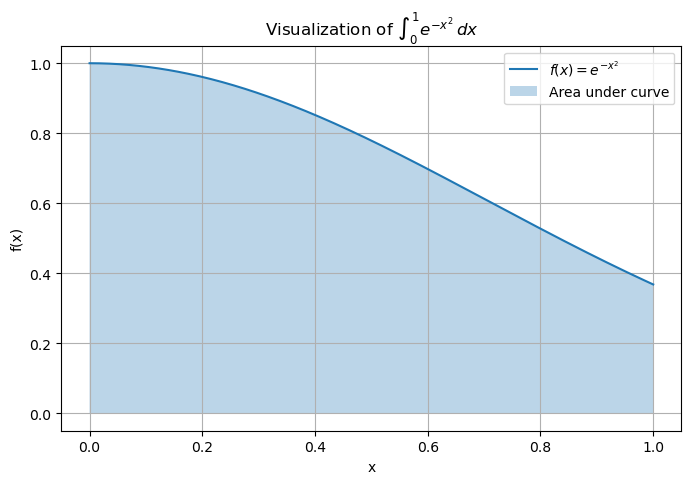

In [6]:
x = np.linspace(a, b, 400)
y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$f(x)=e^{-x^2}$")
plt.fill_between(x, y, alpha=0.3, label="Area under curve")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Visualization of $\int_0^1 e^{-x^2}\,dx$")
plt.legend()
plt.grid(True)
plt.show()

## Initial Observation

The curve is smooth and decreases from \(f(0)=1\) to \(f(1)\approx 0.368\).

The integral represents the area under this smooth curve. Since there is no simple elementary antiderivative for \(e^{-x^2}\), we use numerical methods to approximate the value of the integral.

# Trapezoidal Rule

## Concept

The Trapezoidal Rule approximates the area under a curve by dividing the interval into small subintervals and replacing each curved section with a trapezoid.

For \(n\) subintervals:

\[
h = \frac{b-a}{n}
\]

The approximate integral is:

\[
\int_a^b f(x)\,dx \approx \frac{h}{2}\left[f(x_0)+2\sum_{i=1}^{n-1}f(x_i)+f(x_n)\right]
\]

## Interpretation

- More intervals (\(n\)) → better accuracy  
- Simple and robust  
- Usually less accurate than Simpson’s Rule

In [7]:
def trapezoidal_rule(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)

    h = (b - a) / n

    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

    return integral

## Initial Trapezoidal Approximation

We first test the method using:

\[
n=10
\]

subintervals.

In [8]:
trap_result_10 = trapezoidal_rule(f, a, b, 10)

print("Trapezoidal Rule Approximation (n=10):", trap_result_10)

Trapezoidal Rule Approximation (n=10): 0.7462107961317495


## Convergence Study for Trapezoidal Rule

A single approximation is not enough.

To evaluate numerical behavior properly, we test increasing numbers of subintervals:

\[
n = 10,\; 20,\; 50,\; 100,\; 500,\; 1000
\]

This allows us to observe how accuracy improves as interval size decreases.

In [9]:
n_values = [10, 20, 50, 100, 500, 1000]

trap_results = []

for n in n_values:
    approx = trapezoidal_rule(f, a, b, n)
    trap_results.append((n, approx))

trap_df = pd.DataFrame(trap_results, columns=["n (subintervals)", "Trapezoidal Approximation"])

trap_df

,n (subintervals),Trapezoidal Approximation
0,10,0.746211
1,20,0.746671
2,50,0.746800
3,100,0.746818
4,500,0.746824
5,1000,0.746824


## Interpretation

As \(n\) increases:

- Step size decreases
- More trapezoids are used
- Approximation should stabilize toward the true value

This demonstrates numerical convergence.

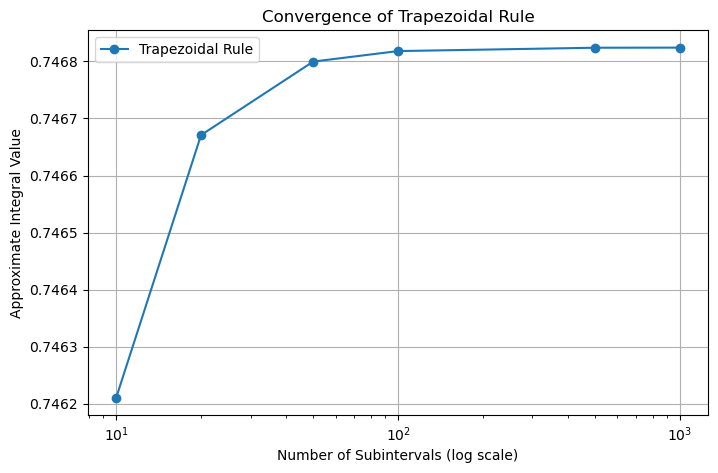

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    trap_df["n (subintervals)"],
    trap_df["Trapezoidal Approximation"],
    marker='o',
    label="Trapezoidal Rule"
)

plt.xscale("log")

plt.xlabel("Number of Subintervals (log scale)")
plt.ylabel("Approximate Integral Value")
plt.title("Convergence of Trapezoidal Rule")
plt.legend()
plt.grid(True)
plt.show()

# Simpson's Rule

## Concept

Simpson’s Rule improves numerical integration accuracy by approximating sections of the function using quadratic (parabolic) curves instead of straight lines.

For an even number of subintervals \(n\):

\[
h = \frac{b-a}{n}
\]

\[
\int_a^b f(x)\,dx \approx \frac{h}{3}\left[f(x_0)+4\sum_{\text{odd}} f(x_i)+2\sum_{\text{even}} f(x_i)+f(x_n)\right]
\]

## Interpretation

Compared to Trapezoidal Rule:

- Usually much more accurate
- Faster convergence
- Requires \(n\) to be even

In [11]:
def simpsons_rule(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson's Rule.")

    x = np.linspace(a, b, n + 1)
    y = f(x)

    h = (b - a) / n

    integral = (h / 3) * (
        y[0]
        + 4 * np.sum(y[1:-1:2])
        + 2 * np.sum(y[2:-2:2])
        + y[-1]
    )

    return integral

## Initial Simpson's Rule Approximation

We begin with:

\[
n=10
\]

(10 is valid because it is even.)

In [13]:
simpson_result_10 = simpsons_rule(f, a, b, 10)

print("Simpson's Rule Approximation (n=10):", simpson_result_10)

Simpson's Rule Approximation (n=10): 0.7468249482544436


## Convergence Study for Simpson's Rule

To compare numerical performance rigorously, we evaluate Simpson’s Rule across increasing even values of \(n\):

\[
n = 10,\; 20,\; 50,\; 100,\; 500,\; 1000
\]

This allows us to compare convergence speed against the Trapezoidal Rule.

In [14]:
simpson_results = []

for n in n_values:
    if n % 2 == 0:
        approx = simpsons_rule(f, a, b, n)
        simpson_results.append((n, approx))

simpson_df = pd.DataFrame(
    simpson_results,
    columns=["n (subintervals)", "Simpson Approximation"]
)

simpson_df

,n (subintervals),Simpson Approximation
0,10,0.746825
1,20,0.746824
2,50,0.746824
3,100,0.746824
4,500,0.746824
5,1000,0.746824


## Interpretation

Simpson’s Rule should typically converge faster than the Trapezoidal Rule because quadratic interpolation better captures smooth curvature.

For smooth functions like \(e^{-x^2}\), Simpson’s Rule is generally expected to outperform Trapezoidal Rule significantly.

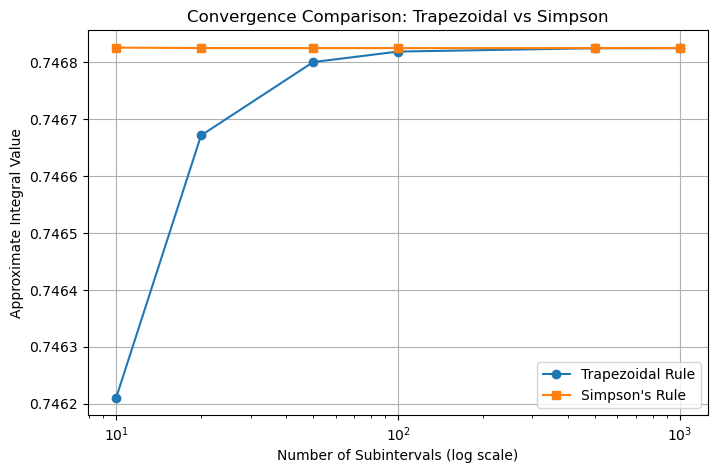

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    trap_df["n (subintervals)"],
    trap_df["Trapezoidal Approximation"],
    marker='o',
    label="Trapezoidal Rule"
)

plt.plot(
    simpson_df["n (subintervals)"],
    simpson_df["Simpson Approximation"],
    marker='s',
    label="Simpson's Rule"
)

plt.xscale("log")

plt.xlabel("Number of Subintervals (log scale)")
plt.ylabel("Approximate Integral Value")
plt.title("Convergence Comparison: Trapezoidal vs Simpson")
plt.legend()
plt.grid(True)
plt.show()

# Monte Carlo Integration

## Concept

Monte Carlo Integration estimates a definite integral using random sampling.

For:

\[
I = \int_a^b f(x)\,dx
\]

We randomly sample points in the interval \([a,b]\), evaluate the function, and estimate:

\[
I \approx (b-a)\times \text{average}(f(x_i))
\]

## Interpretation

Unlike Trapezoidal or Simpson’s Rule:

- Uses randomness
- Useful for complex or high-dimensional integrals
- Typically slower convergence for simple 1D smooth functions
- Powerful for advanced computational problems

In [17]:
def monte_carlo_integration(f, a, b, n):
    x_random = np.random.uniform(a, b, n)

    y_random = f(x_random)

    integral = (b - a) * np.mean(y_random)

    return integral

## Initial Monte Carlo Approximation

Because Monte Carlo uses randomness, results vary slightly between runs.

We begin with:

\[
n = 10,000
\]

random samples.

In [19]:
np.random.seed(42)  # ensures reproducibility

mc_result_10000 = monte_carlo_integration(f, a, b, 10000)

print("Monte Carlo Approximation (n=10000):", mc_result_10000)

Monte Carlo Approximation (n=10000): 0.751074358110783


## Convergence Study for Monte Carlo Integration

Monte Carlo accuracy improves statistically as sample size increases.

We test:

\[
n = 100,\; 1000,\; 10,000,\; 100,000
\]

This allows us to compare probabilistic convergence against deterministic numerical methods.

In [20]:
mc_n_values = [100, 1000, 10000, 100000]

mc_results = []

np.random.seed(42)

for n in mc_n_values:
    approx = monte_carlo_integration(f, a, b, n)
    mc_results.append((n, approx))

mc_df = pd.DataFrame(
    mc_results,
    columns=["n (random samples)", "Monte Carlo Approximation"]
)

mc_df

,n (random samples),Monte Carlo Approximation
0,100,0.765061
1,1000,0.748262
2,10000,0.750142
3,100000,0.746744


## Interpretation

Monte Carlo convergence is usually noisier than Trapezoidal or Simpson’s Rule because of random sampling.

For simple smooth 1D integrals, Monte Carlo is generally less efficient, but it becomes highly valuable in:

- High-dimensional integration
- Statistical physics
- Machine learning
- Computational finance

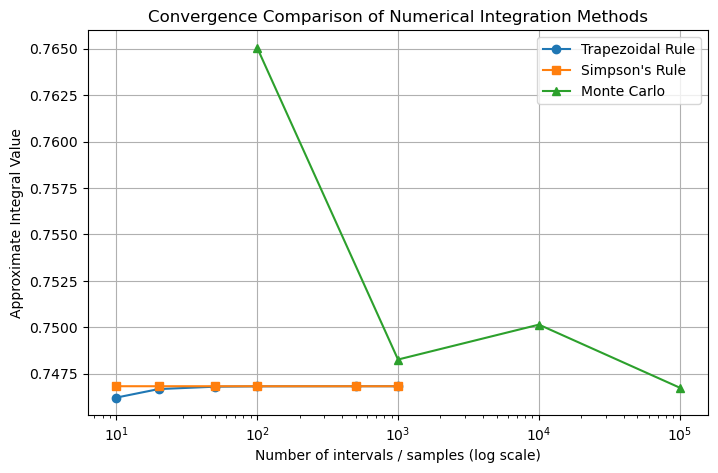

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    trap_df["n (subintervals)"],
    trap_df["Trapezoidal Approximation"],
    marker='o',
    label="Trapezoidal Rule"
)

plt.plot(
    simpson_df["n (subintervals)"],
    simpson_df["Simpson Approximation"],
    marker='s',
    label="Simpson's Rule"
)

plt.plot(
    mc_df["n (random samples)"],
    mc_df["Monte Carlo Approximation"],
    marker='^',
    label="Monte Carlo"
)

plt.xscale("log")

plt.xlabel("Number of intervals / samples (log scale)")
plt.ylabel("Approximate Integral Value")
plt.title("Convergence Comparison of Numerical Integration Methods")
plt.legend()
plt.grid(True)
plt.show()

# Comparative Accuracy Analysis

## Goal

To compare methods rigorously, we calculate a high-accuracy reference value using a very fine Simpson’s Rule approximation.

This acts as our practical “true value” benchmark.

In [23]:
true_value = simpsons_rule(f, a, b, 100000)

print("Reference Value (High-Accuracy Simpson):", true_value)

Reference Value (High-Accuracy Simpson): 0.746824132812427


## Error Definition

For each method:

\[
\text{Absolute Error} = |\text{Approximation} - \text{Reference Value}|
\]

This allows objective numerical comparison.

In [25]:
best_trap = trap_df.iloc[-1]["Trapezoidal Approximation"]
best_simpson = simpson_df.iloc[-1]["Simpson Approximation"]
best_mc = mc_df.iloc[-1]["Monte Carlo Approximation"]

comparison_data = {
    "Method": ["Trapezoidal Rule", "Simpson's Rule", "Monte Carlo"],
    "Best Approximation": [best_trap, best_simpson, best_mc],
    "Absolute Error": [
        abs(best_trap - true_value),
        abs(best_simpson - true_value),
        abs(best_mc - true_value)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Method,Best Approximation,Absolute Error
0,Trapezoidal Rule,0.746824,6.131324e-08
1,Simpson's Rule,0.746824,8.104628e-15
2,Monte Carlo,0.746744,8.014315e-05


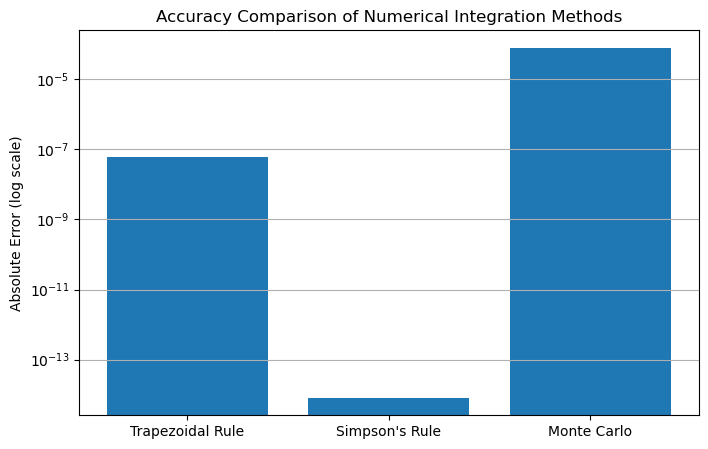

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Absolute Error"]
)

plt.yscale("log")

plt.ylabel("Absolute Error (log scale)")
plt.title("Accuracy Comparison of Numerical Integration Methods")
plt.grid(True, axis='y')
plt.show()

# Final Comparative Analysis

## Trapezoidal Rule
### Strengths:
- Simple to implement
- Robust and intuitive
- Reliable for many smooth functions

### Limitations:
- Slower convergence
- Lower accuracy than Simpson’s Rule for smooth curves

---

## Simpson's Rule
### Strengths:
- Highest accuracy for smooth 1D functions
- Fast convergence
- Excellent balance of efficiency and precision

### Limitations:
- Requires even number of intervals
- Slightly more restrictive mathematically

---

## Monte Carlo Integration
### Strengths:
- Flexible
- Powerful for high-dimensional problems
- Useful in computational finance, physics, and machine learning

### Limitations:
- Noisy convergence
- Less efficient for simple low-dimensional smooth functions

---

# Overall Conclusion

For the test integral:

\[
\int_0^1 e^{-x^2}\,dx
\]

### Observed Performance:
- Simpson’s Rule was the most accurate
- Trapezoidal Rule converged steadily but more slowly
- Monte Carlo was the least efficient for this smooth 1D case, though conceptually powerful

## Key Insight:
Different numerical integration methods balance:

### Accuracy  
### Speed  
### Generality  

For smooth one-dimensional integrals, Simpson’s Rule is typically the strongest classical method.